This script loads all the raw density profiles and puts them in a dict which is then pickled. 

this script replaces... "smoothprofiles.ipynb" and "prepare_egrip_data.ipynb"



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from density_core import DensityCore
import dataclasses

# from pygam import LinearGAM, s  # , te

plt.style.use("aslak")


rhoi = 921  # used to calculate rho_hat
g = 9.82
sec_per_year = 365.25 * 24 * 60 * 60

# EGRIP values
bdot = 0.11 * rhoi
T = -31
rho_surf = 327  # from EGsune which is pit based.


s51biasfun = lambda zz: 1 + (0.5 + 0.5 * np.tanh((zz - 45) / 20)) * 0.045
s51biasfun = lambda zz: 1


# These are plotting helpers. maybe should be moved to a separate file?
symlog = lambda x, thres: np.sign(x) * (np.log(1 + np.abs(x) / thres))
symexp = lambda y, thres: np.sign(y) * thres * (np.exp(y) - 1)
forward_transform = lambda rho: -symlog(rhoi - rho, 1.0)
inverse_transform = lambda x: rhoi - symexp(-x, 1.0)

In [3]:
egsune = pd.read_csv("egrip/sune/egrip_density_iceeqdepth.txt", sep="\\s+", comment="%", names=["z", "rho"], usecols=[0, 1])
egsune = egsune[egsune.z < 170]  # crop to firn. #TOP BASED ON TRENCH!

# this is from VAS. I believe this is the same data that sune uses. But maybe near surface is different?
eg = pd.read_csv("egrip/egrip_density.txt", sep="\\s+", header=0, names=["z", "rho"])
eg.sort_values(by="z", inplace=True)

# JOHANNES FREITAG'S DATA.
s6 = pd.read_excel("egrip/johannes_freitag/Density_EGRIP_S6_ExS5-1_ExS5-2.xlsx", header=0, names=["z", "rho"], usecols=[0, 1]).dropna()
s5_2 = pd.read_excel("egrip/johannes_freitag/Density_EGRIP_S6_ExS5-1_ExS5-2.xlsx", header=0, names=["z", "rho"], usecols=[2, 3]).dropna()
s5_1 = pd.read_excel("egrip/johannes_freitag/Density_EGRIP_S6_ExS5-1_ExS5-2.xlsx", header=0, names=["z", "rho"], usecols=[4, 5]).dropna()
s6.rho = s6.rho * 1000
s5_1.rho = s5_1.rho * 1000
s5_2.rho = s5_2.rho * 1000

s5_1hxct = pd.read_csv("egrip/johannes_freitag/Density_S5_1_HXCT.txt", sep="\\s+").dropna()
s5_1hxct = s5_1hxct.rename(columns={"avgdepth_m": "z", "avg_density": "rho"})
s5_1hxct.rho = s5_1hxct.rho * 1000

# establish BIAS function

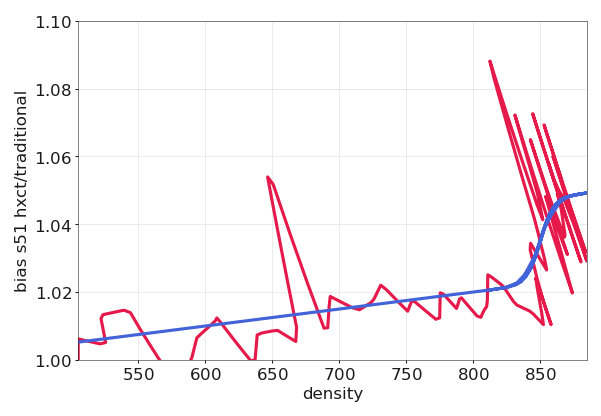

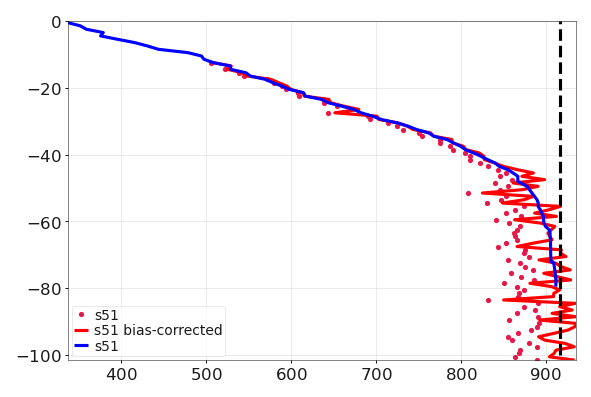

In [ ]:
z = np.linspace(0, np.max(s5_1hxct.z.values), 300)


# z = s5_1.z.values  # for testing. should be removed.
def concave_fit(zp, rhop, z, rhos=rho_surf, n_splines=20):
    X = zp.ravel()
    y = rhop.ravel()
    weights = np.ones_like(y)
    if rhos and np.min(X >= 0):
        X = np.append(0, X)
        y = np.append(rhos, y)
        weights = np.append(100.0, weights)  # should this be a parameter
    mygam = LinearGAM(s(0, n_splines=n_splines, constraints=["monotonic_inc", "concave"]), lam=1).fit(X, y, weights=weights)
    # z = np.arange(np.min(zp),np.max(zp),dz)
    rho = mygam.predict(z)
    rho[z > np.max(zp)] = np.nan  # do not extrapolate
    return rho


# r1 = concave_fit(s5_1.z.values, s5_1.rho.values, z, rhos=rho_surf, n_splines=25)
r1 = np.interp(z, s5_1.z.values, s5_1.rho.values)
# r2 = concave_fit(s5_1hxct.z.values, s5_1hxct.rho.values, z, rhos=rho_surf, n_splines=25)
r2 = np.interp(z, s5_1hxct.z.values, s5_1hxct.rho.values)
bias = r2 / r1

sigmoid = lambda x: 1 / (1 + np.exp(-x))
s51_bias_fun = lambda rho: 1 + (rho - 400) / 400 * 0.02 + sigmoid((rho - 850) / 5) * 0.025

plt.ylim([1, 1.1])
plt.plot(r1, bias)
plt.plot(r1, s51_bias_fun(r1))
plt.ylabel("bias s51 hxct/traditional")
plt.xlabel("density")
plt.figure()
plt.plot(s5_1.rho.values, -s5_1.z.values, ".", label="s51")
plt.plot(s5_1.rho.values * s51_bias_fun(s5_1.rho.values), -s5_1.z.values, "r-", label="s51 bias-corrected")
plt.plot(s5_1hxct.rho.values, -s5_1hxct.z.values, "b-", label="s51")
# plt.plot(z, s51_bias_fun(r1))
plt.plot([917, 917], [-100, 0], "k--")
plt.legend()

In [ ]:
# testing saving and loading
from density_core import DensityCore

S6 = DensityCore(site_name="S6", lat=75.6206, lon=-35.971, T=T, bdot=bdot)
S51 = DensityCore(site_name="S5-1", lat=75.5682717, lon=-35.58572833, T=T, bdot=bdot)
S52 = DensityCore(site_name="S5-2", lat=75.59975, lon=-35.51035, T=T, bdot=bdot)
EG = dataclasses.replace(S6, site_name="EGRIP")
S51hxct = dataclasses.replace(S51, site_name="S5-1hxct")
EGsune = dataclasses.replace(S6, site_name="EGRIP-sune")
S52biasadj = dataclasses.replace(S52, site_name="S5-2adj")

S6.set_density_profile(s6.z.values, s6.rho.values, is_smooth=False, rhos=rho_surf)
S51.set_density_profile(s5_1.z.values, s5_1.rho.values, is_smooth=False, rhos=rho_surf)
S51hxct.set_density_profile(s5_1hxct.z.values, s5_1hxct.rho.values, is_smooth=False, rhos=rho_surf)
S52.set_density_profile(s5_2.z.values, s5_2.rho.values, is_smooth=False, rhos=rho_surf)
EG.set_density_profile(eg.z.values, eg.rho.values, is_smooth=False, rhos=rho_surf)
EGsune.set_density_profile(egsune.z.values, egsune.rho.values, is_smooth=True, rhos=rho_surf)
S52biasadj.set_density_profile(s5_2.z.values, s5_2.rho.values * s51_bias_fun(s5_2.rho.values), is_smooth=False, rhos=rho_surf)

outputfolder = "_prepared_data"

cores = [S6, S51, S52, EG, EGsune, S52biasadj, S51hxct]
for core in cores:
    core.save(f"{outputfolder}/{core.site_name}_density_core.pkl")

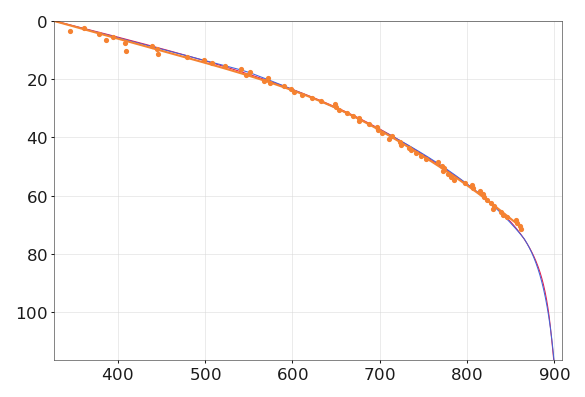

In [ ]:
# plot all at EGRIP
EG.plot(lw=0.5)
EGsune.plot(lw=0.5)
S6.plot(show_raw=True, lw=1)

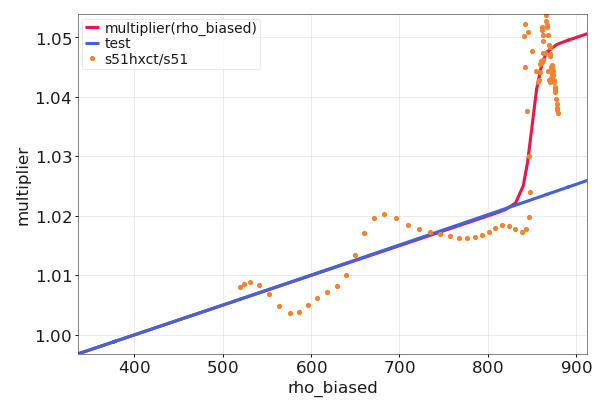

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("aslak")

sigmoid = lambda x: 1 / (1 + np.exp(-x))
s51_bias_fun = lambda rho: 1 + (rho - 400) / 400 * 0.02 + sigmoid((rho - 850) / 5) * 0.025

z = s5_1.z.values
r1 = np.interp(z, s5_1.z.values, s5_1.rho.values)
# r2 = concave_fit(s5_1hxct.z.values, s5_1hxct.rho.values, z, rhos=rho_surf, n_splines=25)
r2 = np.interp(z, s5_1hxct.z.values, s5_1hxct.rho.values)
bias = r2 / r1

from scipy.ndimage import gaussian_filter1d

rho = s5_1hxct.rho.values
plt.plot(rho, s51_bias_fun(rho), label="multiplier(rho_biased)")
plt.plot(rho, np.exp((rho - 400) / 20000), label="test")
plt.plot(gaussian_filter1d(r1, 2), gaussian_filter1d(bias, 2), ".", label="s51hxct/s51")
plt.xlabel("rho_biased")
plt.ylabel("multiplier")
plt.legend()